# XGBoost, LightGBM, CatBoost compared

### Three libraries, one algorithm, and a fair way to tell them apart

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why histogram binning made boosting fast, how level-wise, leaf-wise and oblivious tree growth differ, what native categorical handling buys you over one-hot encoding and when it costs you instead, why target encoding leaks and how CatBoost closes it, how much of the gap between these libraries is the library rather than the settings you gave it, and how a silent NumPy broadcast can hand you an accuracy that no hyperparameter moves |
| **You should already know** | [Gradient boosting from first principles](../05-gradient-boosting/) |
| **Datasets** | UCI Dry Bean (13,611 x 16), UCI Bike Sharing (17,379 x 12) |
| **Runtime** | Three to five minutes on a laptop CPU, longer if you have all four libraries installed |
| **Next** | [04-07 Stacking and voting](../07-stacking-and-voting/) |

---

## 1. What actually differs

The [previous notebook](../05-gradient-boosting/) built gradient boosting from
scratch in about fifteen lines, then used scikit-learn's original
`GradientBoostingRegressor`. That implementation sorts every feature at every
node to find the best split. It is correct, it is slow, and it is why boosting
had a reputation for being impractical on anything large.

Then XGBoost arrived in 2014, LightGBM in 2016, CatBoost in 2017, and
scikit-learn added `HistGradientBoosting` in 2019 after watching what the
others did. All four implement the same algorithm. The mathematics from the
last notebook is untouched: fit a tree to the negative gradient, take a
fraction of the step, repeat.

What changed is engineering, and it comes down to four decisions:

1. **How continuous features are searched.** Exact sorting, or binned into a
   fixed number of buckets first.
2. **How the tree is grown.** Level by level, best-leaf first, or with one
   shared condition per level.
3. **How categorical columns are handled.** You encode them yourself, or the
   library splits on sets of categories directly.
4. **What the defaults are.** This turns out to matter more than the other
   three, and section 5 measures it.

Everything else (regularised leaf weights, column subsampling, early stopping,
missing-value routing), all four have, and they behave much the same way.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

### Which of them do you actually have

Only `HistGradientBoosting` is guaranteed, because it ships inside
scikit-learn. The other three are separate installs, so this notebook looks for
each one and runs the comparison over whichever it finds. Every chart below
renders either way: a missing library is a missing series, not an error.

In [2]:
import time
import warnings

import sklearn

# LightGBM and CatBoost are chatty about parameter aliases and pandas category
# dtypes. None of it changes a result, and it drowns out the prints.
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


def optional_import(module_name):
    """Import a library if it is installed, otherwise return None."""
    try:
        module = __import__(module_name)
        return module, getattr(module, "__version__", "unknown")
    except ImportError:
        return None, None


xgb, XGB_VERSION = optional_import("xgboost")
lgb, LGB_VERSION = optional_import("lightgbm")
cb, CB_VERSION = optional_import("catboost")

LIBRARIES = {
    "HistGB": {"found": True, "version": sklearn.__version__,
               "install": "ships with scikit-learn",
               "growth": "leaf-wise", "categorical": "yes, by column name"},
    "XGBoost": {"found": xgb is not None, "version": XGB_VERSION or "-",
                "install": "pip install xgboost",
                "growth": "level-wise by default", "categorical": "yes, opt in"},
    "LightGBM": {"found": lgb is not None, "version": LGB_VERSION or "-",
                 "install": "pip install lightgbm",
                 "growth": "leaf-wise", "categorical": "yes, automatic"},
    "CatBoost": {"found": cb is not None, "version": CB_VERSION or "-",
                 "install": "pip install catboost",
                 "growth": "oblivious", "categorical": "yes, ordered statistics"},
}

CONTENDERS = [name for name, spec in LIBRARIES.items() if spec["found"]]
MISSING = [name for name, spec in LIBRARIES.items() if not spec["found"]]

print(pd.DataFrame([
    {"library": name,
     "installed": "yes" if spec["found"] else "no",
     "version": spec["version"],
     "tree growth": spec["growth"],
     "categorical": spec["categorical"],
     "get it with": spec["install"]}
    for name, spec in LIBRARIES.items()
]).to_string(index=False))

print(f"\ncomparing: {', '.join(CONTENDERS)}")
if MISSING:
    print(f"absent   : {', '.join(MISSING)}")
    print("Every figure still renders. For the full comparison, run:")
    print("    pip install " + " ".join(name.lower() for name in MISSING))
else:
    print("all four present, so every chart below has four series")

 library installed version           tree growth             categorical             get it with
  HistGB       yes   1.8.0             leaf-wise     yes, by column name ships with scikit-learn
 XGBoost       yes   3.2.0 level-wise by default             yes, opt in     pip install xgboost
LightGBM       yes   4.6.0             leaf-wise          yes, automatic    pip install lightgbm
CatBoost       yes  1.2.10             oblivious yes, ordered statistics    pip install catboost

comparing: HistGB, XGBoost, LightGBM, CatBoost
all four present, so every chart below has four series


## 2. Histogram binning

This is the change that made boosting fast, and it is worth understanding
properly because everything else is a smaller effect.

### The exact method

To split a node on a continuous feature, the honest thing to do is try every
threshold separating two adjacent values. With $n$ rows in the node that is up
to $n - 1$ candidates, and to evaluate them cheaply you first sort the column,
so that a running sum of gradients gives you both sides of every candidate in
one pass. The sort costs $O(n \log n)$, and you pay it for every feature at
every node.

### The binned method

Before training starts, each continuous feature is chopped into a small fixed
number of buckets (255 by default almost everywhere) using quantiles of the
column, and every value is replaced by its bucket number. That is a one-off
cost paid once for the whole dataset, not once per node.

Now a node's split search is: sweep its rows once, adding each gradient into
its bucket, then scan the buckets in order. The sort is gone. The scan is over
`max_bin` positions instead of $n$ of them, and `max_bin` does not grow with
your data.

There is a second trick on top. A node's two children partition its rows, so
the two child histograms sum to the parent's. Build the histogram for the
smaller child, subtract it from the parent, and the larger child arrives free.
That removes roughly half the accumulation work at every level.

Let me measure all three costs separately.

In [3]:
def best_split_exact(x, grad):
    """Sort the column, then evaluate every boundary with a running sum."""
    order = np.argsort(x, kind="quicksort")
    ordered = grad[order]
    left_sum = np.cumsum(ordered)[:-1]
    left_n = np.arange(1, len(ordered), dtype=np.float64)
    right_sum = ordered.sum() - left_sum
    right_n = len(ordered) - left_n
    # Variance-reduction gain, dropping the constant total term.
    gain = left_sum ** 2 / left_n + right_sum ** 2 / right_n
    return float(gain.max())


def build_histogram(codes, grad, n_bins):
    """One pass over the rows. This is the part sibling subtraction avoids."""
    return (np.bincount(codes, weights=grad, minlength=n_bins),
            np.bincount(codes, minlength=n_bins).astype(np.float64))


def best_split_from_histogram(hist_sum, hist_count):
    """Scan the buckets in order. Costs the same whatever n was."""
    left_sum = np.cumsum(hist_sum)[:-1]
    left_n = np.cumsum(hist_count)[:-1]
    right_sum = hist_sum.sum() - left_sum
    right_n = hist_count.sum() - left_n
    with np.errstate(divide="ignore", invalid="ignore"):
        gain = np.where(
            left_n * right_n > 0,
            left_sum ** 2 / np.maximum(left_n, 1.0)
            + right_sum ** 2 / np.maximum(right_n, 1.0),
            -np.inf)
    return float(gain.max())


def timed(call, repeat=3):
    """Best of `repeat` runs, which is the fair way to time on a busy laptop."""
    best = float("inf")
    for _ in range(repeat):
        start = time.perf_counter()
        call()
        best = min(best, time.perf_counter() - start)
    return best


MAX_BIN = 255
rng = np.random.default_rng(SEED)
node_sizes = [10_000, 30_000, 100_000, 300_000, 1_000_000]
cost = {"exact sort and scan": [], "build histogram and scan": [], "scan only": []}

for n in node_sizes:
    x = rng.standard_normal(n)
    grad = rng.standard_normal(n)

    # Binning happens once before the first tree, so it is not a per-node cost.
    edges = np.unique(np.quantile(x, np.linspace(0, 1, MAX_BIN + 1)[1:-1]))
    codes = np.searchsorted(edges, x).astype(np.int32)
    n_bins = len(edges) + 1
    hist_sum, hist_count = build_histogram(codes, grad, n_bins)

    cost["exact sort and scan"].append(timed(lambda: best_split_exact(x, grad)))
    cost["build histogram and scan"].append(
        timed(lambda: best_split_from_histogram(*build_histogram(codes, grad, n_bins))))
    cost["scan only"].append(
        timed(lambda: best_split_from_histogram(hist_sum, hist_count)))

print("milliseconds to find the best split on one feature")
print(f"{'':<26}" + "".join(f"{n:>12,}" for n in node_sizes))
for label, times in cost.items():
    print(f"{label:<26}" + "".join(f"{t * 1000:>12.3f}" for t in times))

versus_sort = cost["exact sort and scan"][-1] / cost["build histogram and scan"][-1]
versus_scan = cost["exact sort and scan"][-1] / cost["scan only"][-1]
print(f"\nat one million rows the histogram path is {versus_sort:.1f}x faster than sorting,")
print(f"and {versus_scan:.0f}x faster when the histogram came free by subtraction")

milliseconds to find the best split on one feature
                                10,000      30,000     100,000     300,000   1,000,000
exact sort and scan              0.936       1.869      10.713      28.548     952.152
build histogram and scan         0.188       0.236       0.790       3.799      69.636
scan only                        0.076       0.046       0.077       0.062       0.045

at one million rows the histogram path is 13.7x faster than sorting,
and 21206x faster when the histogram came free by subtraction


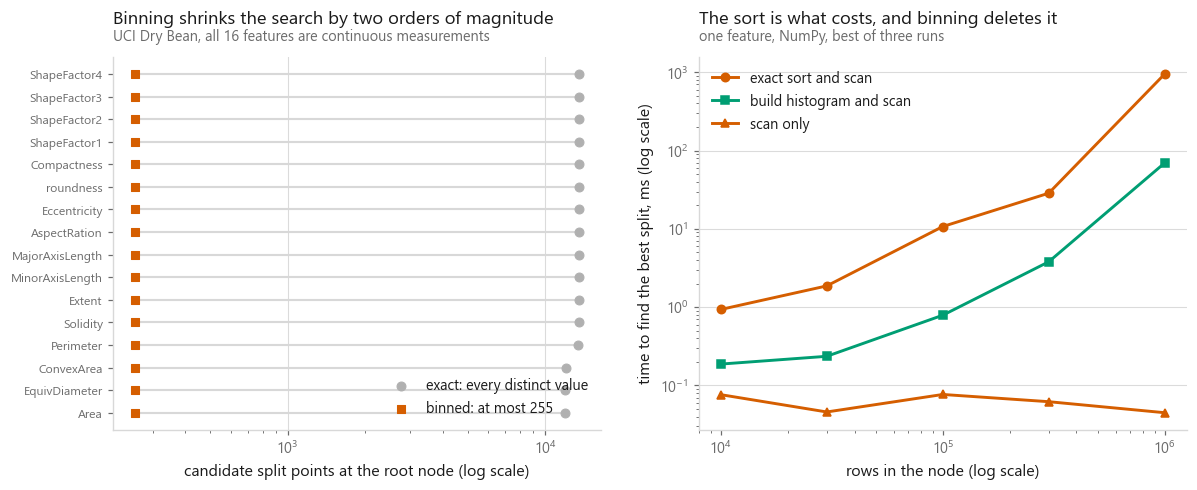

In [4]:
X_bean, y_bean = datasets.dry_bean()
unique_counts = X_bean.nunique().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

positions = np.arange(len(unique_counts))
axes[0].hlines(positions, np.minimum(unique_counts.values, MAX_BIN), unique_counts.values,
               color=style.RULE, lw=1.4, zorder=1)
axes[0].scatter(unique_counts.values, positions, color=style.NEUTRAL,
                marker=style.MARKERS[0], s=34, zorder=2,
                label="exact: every distinct value")
axes[0].scatter(np.minimum(unique_counts.values, MAX_BIN), positions,
                color=style.HIGHLIGHT, marker=style.MARKERS[1], s=34, zorder=3,
                label=f"binned: at most {MAX_BIN}")
axes[0].set_yticks(positions, list(unique_counts.index), fontsize=8)
axes[0].set_xscale("log")
axes[0].set_xlabel("candidate split points at the root node (log scale)")
axes[0].grid(axis="y", visible=False)
axes[0].grid(axis="x", visible=True)
axes[0].legend(loc="lower right")
style.title(axes[0], "Binning shrinks the search by two orders of magnitude",
            "UCI Dry Bean, all 16 features are continuous measurements")

for i, (label, times) in enumerate(cost.items()):
    axes[1].plot(node_sizes, [t * 1000 for t in times], marker=style.MARKERS[i],
                 color=style.HIGHLIGHT if i == 0 else style.PALETTE[i + 1], label=label)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("rows in the node (log scale)")
axes[1].set_ylabel("time to find the best split, ms (log scale)")
axes[1].legend()
style.title(axes[1], "The sort is what costs, and binning deletes it",
            "one feature, NumPy, best of three runs")

style.save(fig, FIG / "fig-01-histogram-binning.png")

The left panel is why this works at all. Every bean measurement is continuous,
so nearly every row carries a distinct value and the exact method has many
thousands of thresholds to weigh per feature per node. Binning caps that at
`max_bin` regardless of how many rows you have.

The right panel separates the two costs binning replaces. Building the
histogram is still one pass over the rows, so that line climbs with $n$, but
it is a single cheap pass with no comparisons in it. The flat line underneath
is what a node costs when its histogram arrived by subtracting a sibling from a
parent, and flat is the point: that cost does not care how much data you have.

The obvious question is what accuracy this throws away. Fewer bins means
coarser thresholds, so the answer should be "a little, and less as bins go up".

In [5]:
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# XGBoost wants integer class labels, so encode once and use the codes everywhere.
bean_labels = LabelEncoder().fit(y_bean)
y_bean_coded = pd.Series(bean_labels.transform(y_bean), name="Class")

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bean, y_bean_coded, test_size=0.25, random_state=SEED, stratify=y_bean_coded)


def classifier(library, *, n_estimators=200, learning_rate=0.1, num_leaves=31,
               max_bin=255, min_leaf=20, seed=SEED):
    """One configuration, translated into each library's own vocabulary.

    The reason this function exists is that the four libraries use four different
    names for the same five dials, which is most of why casual comparisons
    between them end up unfair.
    """
    if library == "HistGB":
        return HistGradientBoostingClassifier(
            max_iter=n_estimators, learning_rate=learning_rate,
            max_leaf_nodes=num_leaves, max_bins=min(max_bin, 255),
            min_samples_leaf=min_leaf, early_stopping=False, random_state=seed)
    if library == "LightGBM":
        return lgb.LGBMClassifier(
            n_estimators=n_estimators, learning_rate=learning_rate,
            num_leaves=num_leaves, max_bin=max_bin, min_child_samples=min_leaf,
            random_state=seed, n_jobs=-1, verbose=-1)
    if library == "XGBoost":
        # max_depth=0 with lossguide is how XGBoost is asked to grow leaf-wise.
        # min_leaf is deliberately not passed on: XGBoost's guard is
        # min_child_weight, which counts Hessian mass rather than rows, so
        # setting it to the same number would be a stricter rule than the others
        # get. XGBoost keeps its own default here and sits out the sweep below.
        return xgb.XGBClassifier(
            n_estimators=n_estimators, learning_rate=learning_rate,
            max_leaves=num_leaves, max_depth=0, grow_policy="lossguide",
            max_bin=max_bin, tree_method="hist",
            random_state=seed, n_jobs=-1, verbosity=0)
    if library == "CatBoost":
        return cb.CatBoostClassifier(
            iterations=n_estimators, learning_rate=learning_rate,
            max_leaves=num_leaves, grow_policy="Lossguide",
            border_count=min(max_bin, 254), min_data_in_leaf=min_leaf,
            random_seed=seed, verbose=0, thread_count=-1, allow_writing_files=False)
    raise ValueError(library)


def share_correct(predicted, labels):
    """Accuracy, with the one shape difference between these libraries handled.

    The flatten is load-bearing. `CatBoostClassifier.predict` hands back a
    column of shape (n, 1) on a multiclass problem, where the other three
    return a flat (n,). Compared against a flat array of labels with `==`, that
    column broadcasts into an n-by-n matrix instead of raising, and the mean of
    that matrix is the chance two randomly drawn rows share a class. It looks
    exactly like a model stuck near chance that no hyperparameter moves, which
    is how I found it.
    """
    return float((np.asarray(predicted).reshape(-1) == np.asarray(labels)).mean())


# Every library pays a one-off cost on its first fit: loading a compiled
# extension, spinning up a thread pool. Burn that here so it does not land on
# whichever configuration happens to be timed first.
for library in CONTENDERS:
    classifier(library, n_estimators=5).fit(Xb_train.iloc[:400], yb_train.iloc[:400])

fitted = {}   # the last model each library trains here, reused two cells down

print(f"{'library':<10} {'max_bin':>8} {'accuracy':>10} {'fit seconds':>13}")
for library in CONTENDERS:
    for max_bin in [15, 63, 255]:
        model = classifier(library, n_estimators=100, max_bin=max_bin)
        start = time.perf_counter()
        model.fit(Xb_train, yb_train)
        elapsed = time.perf_counter() - start
        score = share_correct(model.predict(Xb_test), yb_test.values)
        print(f"{library:<10} {max_bin:>8} {score:>10.4f} {elapsed:>13.2f}")
        fitted[library] = model

library     max_bin   accuracy   fit seconds


HistGB           15     0.9180          2.39


HistGB           63     0.9239          2.46


HistGB          255     0.9292          2.69


XGBoost          15     0.9227          2.46


...

LightGBM         63     0.9257          1.50


LightGBM        255     0.9301          1.74


CatBoost         15     0.9218          1.44


CatBoost         63     0.9259          1.52


CatBoost        255     0.9254          2.06


Coarse bins cost accuracy and buy time, and the curve flattens quickly. That is
why nobody tunes `max_bin` in practice: the default already sits past the knee.
It is worth turning down when a dataset is too large to be comfortable, because
the bin count also decides how much memory the binned matrix takes.

### Watch out: the shape that comes back from `predict`

Every accuracy in that table came from comparing a vector of predictions
against a vector of labels with `==`. That one line is where this chapter
nearly went wrong, and it is worth seeing done badly, because nothing about it
raises an error.

In [6]:
predicted = {library: np.asarray(fitted[library].predict(Xb_test))
             for library in CONTENDERS}
truth = yb_test.values

print(f"{'library':<10} {'shape from predict':>20}")
for library in CONTENDERS:
    print(f"{library:<10} {str(predicted[library].shape):>20}")

column_shaped = [name for name in CONTENDERS if predicted[name].ndim > 1]
if column_shaped:
    source = column_shaped[0]
    column = predicted[source]
    print(f"\n{source} hands back a column where the others hand back a vector.")
else:
    source = CONTENDERS[0]
    column = predicted[source].reshape(-1, 1)
    print(f"\nNothing installed here returns a column, so {source}'s predictions "
          f"are reshaped into one to make the point.")

broadcast = column == truth
print(f"comparing {column.shape} against {truth.shape} gives {broadcast.shape}, "
      f"and raises nothing at all")

classes = np.unique(truth)
label_share = np.array([(truth == c).mean() for c in classes])
prediction_share = np.array([(column.reshape(-1) == c).mean() for c in classes])

print(f"\nmean of that matrix                  {broadcast.mean():>9.4f}")
print(f"chance two random rows share a class {float(prediction_share @ label_share):>9.4f}")
print(f"the same sum using the labels twice  {float(label_share @ label_share):>9.4f}")
print(f"accuracy once the column is flat     {share_correct(column, truth):>9.4f}")

library      shape from predict
HistGB                  (3403,)
XGBoost                 (3403,)
LightGBM                (3403,)
CatBoost              (3403, 1)

CatBoost hands back a column where the others hand back a vector.


comparing (3403, 1) against (3403,) gives (3403, 3403), and raises nothing at all

mean of that matrix                     0.1739
chance two random rows share a class    0.1739
the same sum using the labels twice     0.1729
accuracy once the column is flat        0.9254


The mean of that matrix is not an accuracy. It is the chance that a randomly
drawn prediction and a randomly drawn label name the same class, which is a
property of the class balance and has almost nothing to do with the model.
The first two numbers printed above agree to every digit shown, because they
are the same sum written two ways. The third replaces the model's class shares
with the labels' own, and lands in the same place, which is the giveaway: a
score this insensitive to the model is really a description of the dataset.

The part to take away is what such a score does when you tune. A wrong number
usually still moves when you change a setting, even if it moves to the wrong
place. This one sits still through every value of `max_bin`, every leaf budget
and every learning rate, because none of those change the class balance. A
score that does not respond to any setting at all is not a badly tuned model.
It is a number that was never measuring the model.

NumPy is doing exactly what it promises here. The mistake was assuming four
libraries agree on the shape of an answer.

## 3. Level-wise against leaf-wise

Given a budget of splits, where do you spend them?

**Level-wise**, which is XGBoost's default: split every node on the current
level before starting the next one. The tree stays balanced and `max_depth`
controls its size exactly.

**Leaf-wise**, which is LightGBM's only mode and also what scikit-learn's
`HistGradientBoosting` does: keep a queue of leaves ordered by the gain each
would produce if split, and always split the best one. The tree comes out
lopsided, sometimes very deep down one branch and shallow everywhere else.

**Oblivious**, which is CatBoost's default: pick one split condition per level
and apply it at every node on that level. The tree is perfectly balanced, and
every leaf is reached by the same sequence of yes/no answers, so prediction
becomes an index into an array rather than a walk down pointers. That is where
CatBoost's prediction speed comes from. It is also heavy regularisation,
because the tree has far less freedom than the other two.

For a fixed number of splits, leaf-wise drives the training loss down the most,
because it spends every split where the gain is largest. That is exactly why it
is the easiest of the three to overfit with.

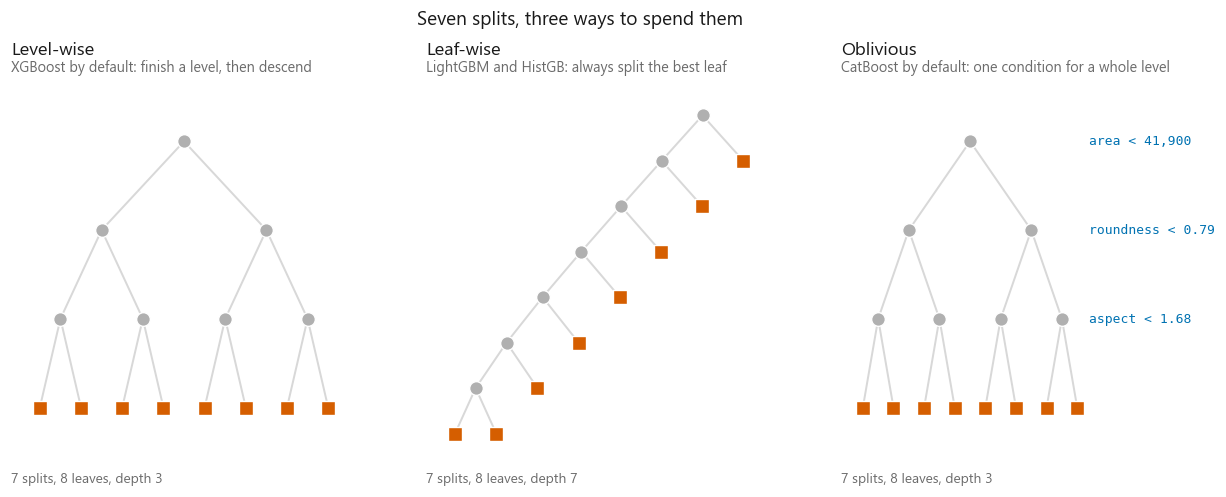

In [7]:
def draw_tree(ax, children, headline, sub, level_labels=None):
    """Draw a small binary tree. Leaves are laid out left to right and parents
    sit at the midpoint of their children, which keeps any shape readable."""
    pos, next_leaf = {}, [0]

    def place(node, depth):
        kids = children.get(node)
        if not kids:
            pos[node] = (next_leaf[0], -depth)
            next_leaf[0] += 1
            return pos[node][0]
        left = place(kids[0], depth + 1)
        right = place(kids[1], depth + 1)
        pos[node] = ((left + right) / 2, -depth)
        return pos[node][0]

    place(0, 0)
    internal = set(children)

    for parent, kids in children.items():
        for kid in kids:
            ax.plot([pos[parent][0], pos[kid][0]], [pos[parent][1], pos[kid][1]],
                    color=style.RULE, lw=1.3, zorder=1, solid_capstyle="round")
    for node, (x, y) in pos.items():
        leaf = node not in internal
        ax.scatter([x], [y], s=95 if leaf else 80, zorder=2,
                   marker="s" if leaf else "o",
                   color=style.HIGHLIGHT if leaf else style.NEUTRAL,
                   edgecolor="white", linewidth=0.9)

    depth = int(max(-y for _, y in pos.values()))
    ax.annotate(f"{len(internal)} splits, {len(pos) - len(internal)} leaves, depth {depth}",
                xy=(0.0, 0.0), xycoords="axes fraction", xytext=(0, -8),
                textcoords="offset points", ha="left", va="top",
                fontsize=9, color=style.MUTED)

    right_edge = max(x for x, _ in pos.values())
    if level_labels:
        for level, text in enumerate(level_labels):
            ax.text(right_edge + 0.4, -level, text, fontsize=8.5,
                    color=style.PALETTE[0], va="center", ha="left", family="monospace")

    ax.set_xlim(-0.7, right_edge + (3.6 if level_labels else 0.7))
    ax.set_ylim(-depth - 0.6, 0.6)
    ax.axis("off")
    style.title(ax, headline, sub)


# The same budget of seven splits in all three, spent three different ways.
level_wise = {0: (1, 2), 1: (3, 4), 2: (5, 6), 3: (7, 8), 4: (9, 10), 5: (11, 12), 6: (13, 14)}
leaf_wise = {0: (1, 2), 1: (3, 4), 3: (5, 6), 5: (7, 8), 7: (9, 10), 9: (11, 12), 11: (13, 14)}

fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.4))
draw_tree(axes[0], level_wise, "Level-wise",
          "XGBoost by default: finish a level, then descend")
draw_tree(axes[1], leaf_wise, "Leaf-wise",
          "LightGBM and HistGB: always split the best leaf")
draw_tree(axes[2], level_wise, "Oblivious",
          "CatBoost by default: one condition for a whole level",
          level_labels=["area < 41,900", "roundness < 0.79", "aspect < 1.68"])
fig.suptitle("Seven splits, three ways to spend them",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-growth-strategies.png")

### What leaf-wise costs you on small data

A leaf-wise tree with 31 leaves can be thirty levels deep down one branch, and
the leaf at the bottom of that branch may hold a handful of rows. On a large
dataset that is fine, because a deep branch still contains plenty of rows. On a
small dataset it is memorisation.

LightGBM's own documentation tells you to lower `num_leaves` on small data, and
ignoring that is the most common way to get a bad result out of it. Below I
train on a deliberately small slice, sweep the leaf budget, and run the whole
sweep twice: once with the default minimum rows per leaf, and once with that
guard turned off.

In [8]:
small_train, small_test, small_y_train, small_y_test = train_test_split(
    X_bean, y_bean_coded, train_size=900, test_size=3000,
    random_state=SEED, stratify=y_bean_coded)

leaf_budgets = [2, 4, 8, 16, 32, 64, 128]

# XGBoost has no minimum-rows-per-leaf setting at all: its guard counts Hessian
# mass, so it cannot be put on the same axis as the other three.
ROW_GUARD_LIBRARIES = [name for name in CONTENDERS if name != "XGBoost"]

print("25 trees on 900 rows. train accuracy / held-out accuracy\n")
guard_curve = {}   # (library, min_leaf) -> {"train": [...], "test": [...]}
for library in ROW_GUARD_LIBRARIES:
    for min_leaf, label in [(20, "default guard, 20 rows"), (1, "guard off, 1 row")]:
        cells, train_curve, test_curve = [], [], []
        for leaves in leaf_budgets:
            model = classifier(library, n_estimators=25, num_leaves=leaves, min_leaf=min_leaf)
            model.fit(small_train, small_y_train)
            train_accuracy = share_correct(model.predict(small_train), small_y_train.values)
            test_accuracy = share_correct(model.predict(small_test), small_y_test.values)
            train_curve.append(train_accuracy)
            test_curve.append(test_accuracy)
            cells.append(f"{leaves:>3}: {train_accuracy:.3f}/{test_accuracy:.3f}")
        guard_curve[(library, min_leaf)] = {"train": train_curve, "test": test_curve}
        print(f"{library:<10} {label:<24} " + "  ".join(cells))
    print()

# Read the verdict off the table rather than asserting it, because these
# libraries do not all do the same thing here and the interesting one is the
# library that refuses to memorise.
MEMORISED = 0.995
peak_train = {name: max(guard_curve[(name, 1)]["train"]) for name in ROW_GUARD_LIBRARIES}
tail_spread = {name: max(guard_curve[(name, 20)]["test"][-4:])
                     - min(guard_curve[(name, 20)]["test"][-4:])
               for name in ROW_GUARD_LIBRARIES}

memorisers = [n for n in ROW_GUARD_LIBRARIES if peak_train[n] >= MEMORISED]
holdouts = [n for n in ROW_GUARD_LIBRARIES if peak_train[n] < MEMORISED]

print("with the guard off, peak training accuracy reached:")
for library in ROW_GUARD_LIBRARIES:
    print(f"  {library:<10} {peak_train[library]:.3f}")

if memorisers:
    print(f"\n{' and '.join(memorisers)} {'gets' if len(memorisers) == 1 else 'get'} to an "
          f"effectively perfect training score once the")
    print("guard is off, and held-out accuracy peaks early and then falls back.")
if holdouts:
    print(f"{' and '.join(holdouts)} {'stops' if len(holdouts) == 1 else 'stop'} well short "
          f"of that with the same guard removed.")

print("\nwith the guard on, held-out accuracy across the largest four leaf budgets moves:")
for library in ROW_GUARD_LIBRARIES:
    print(f"  {library:<10} {tail_spread[library]:.3f}")
print("The leaf budget stops mattering past the middle of the range, because the")
print("minimum rows per leaf binds first.")

if "XGBoost" in CONTENDERS:
    print("\nXGBoost is not in this sweep: it has no minimum-rows-per-leaf setting,")
    print("only min_child_weight, which is measured in Hessian mass.")

25 trees on 900 rows. train accuracy / held-out accuracy



HistGB     default guard, 20 rows     2: 0.923/0.888    4: 0.957/0.910    8: 0.991/0.909   16: 0.997/0.904   32: 0.999/0.903   64: 0.999/0.904  128: 0.999/0.904


HistGB     guard off, 1 row           2: 0.923/0.888    4: 0.962/0.910    8: 1.000/0.899   16: 1.000/0.892   32: 1.000/0.895   64: 1.000/0.888  128: 1.000/0.885



LightGBM   default guard, 20 rows     2: 0.921/0.889    4: 0.954/0.910    8: 0.989/0.909   16: 0.994/0.910   32: 0.994/0.910   64: 0.994/0.910  128: 0.994/0.910


LightGBM   guard off, 1 row           2: 0.921/0.889    4: 0.961/0.913    8: 0.998/0.902   16: 1.000/0.892   32: 1.000/0.884   64: 1.000/0.884  128: 1.000/0.884



CatBoost   default guard, 20 rows     2: 0.822/0.808    4: 0.898/0.893    8: 0.919/0.902   16: 0.941/0.903   32: 0.942/0.905   64: 0.940/0.903  128: 0.940/0.903


CatBoost   guard off, 1 row           2: 0.822/0.808    4: 0.899/0.895    8: 0.917/0.894   16: 0.928/0.906   32: 0.939/0.907   64: 0.940/0.906  128: 0.940/0.906

with the guard off, peak training accuracy reached:
  HistGB     1.000
  LightGBM   1.000
  CatBoost   0.940

HistGB and LightGBM get to an effectively perfect training score once the
guard is off, and held-out accuracy peaks early and then falls back.
CatBoost stops well short of that with the same guard removed.

with the guard on, held-out accuracy across the largest four leaf budgets moves:
  HistGB     0.001
  LightGBM   0.001
  CatBoost   0.002
The leaf budget stops mattering past the middle of the range, because the
minimum rows per leaf binds first.

XGBoost is not in this sweep: it has no minimum-rows-per-leaf setting,
only min_child_weight, which is measured in Hessian mass.


That second row is the more useful lesson, and it was not the one I expected to
write. I went in thinking `num_leaves` was the dial that protects you from
leaf-wise growth. It is not. The minimum rows per leaf is, and it is switched
on by default in every one of these libraries. Turn it off and the leaf budget
becomes dangerous; leave it alone and raising the leaf budget mostly stops
doing anything, because there is nothing left that is legal to split.

The way that summary divides the libraries is the other thing worth stopping on. HistGB and
LightGBM memorise these rows once the guard is lifted, and CatBoost does not
come close to it. That is ordered boosting doing the job it was designed
for: it fits each row using a model built only from rows earlier in a random
permutation, so a leaf cannot quietly absorb the answer for the rows sitting
inside it. A training slice this small is exactly where that shows up, and it
is the concrete version of the claim that CatBoost is the safe choice on small
data.

## 4. Categorical features

A tree splits on "is this value below that threshold". A category has no below.
So something has to give, and there are three things people do.

**Ordinal codes.** Leave the integer codes in place and let the tree treat them
as numbers. Cheap, and it invents an ordering that is not in the data: it lets
the tree say "weekday < 3", which groups Sunday, Monday and Tuesday for no
reason beyond the order somebody wrote the labels down in.

**One-hot.** One binary column per level. Honest, and it makes the tree work
harder: to isolate a group of five categories out of twenty, the tree needs
five separate splits, each on a column that is mostly zero and therefore has
little gain on its own. Columns multiply too, and with them memory.

**Native.** The library knows the column is categorical and splits it into two
*sets* of categories in one step. LightGBM does this by sorting the categories
by their accumulated gradient and scanning that order as if it were numeric,
which finds a good partition in one pass. CatBoost does something different,
and section 4.2 covers it.

Bike Sharing is the right dataset for this, because `season`, `mnth`, `weekday`
and `weathersit` are genuine labels that arrive as integers and are therefore
very easy to hand a model as if they were quantities.

In [9]:
X_bike, y_bike = datasets.bike_sharing()
CATEGORICAL = ["season", "mnth", "weekday", "weathersit"]

print("Bike Sharing columns and their distinct values")
print(X_bike.nunique().to_string())
print(f"\ntreating as categorical: {', '.join(CATEGORICAL)}")
print(f"one-hot turns those {len(CATEGORICAL)} columns into "
      f"{int(X_bike[CATEGORICAL].nunique().sum())}")


def encode(frame, mode, library, columns):
    """Shape the frame the way this library expects it for this encoding."""
    if mode == "ordinal":
        return frame.astype(float)
    if mode == "one-hot":
        return pd.get_dummies(frame, columns=columns, dtype=float)
    out = frame.copy()
    for column in columns:
        # CatBoost wants the raw labels; the others want a pandas category dtype.
        out[column] = (out[column].astype(str) if library == "CatBoost"
                       else out[column].astype("category"))
    return out


def regressor(library, mode, *, columns=None, n_estimators=300, learning_rate=0.1,
              num_leaves=31):
    native = mode == "native"
    declared = list(columns) if (native and columns) else None
    if library == "HistGB":
        return HistGradientBoostingRegressor(
            max_iter=n_estimators, learning_rate=learning_rate,
            max_leaf_nodes=num_leaves, categorical_features=declared,
            early_stopping=False, random_state=SEED)
    if library == "LightGBM":
        # LightGBM picks up category dtype columns on its own, nothing to declare.
        return lgb.LGBMRegressor(
            n_estimators=n_estimators, learning_rate=learning_rate,
            num_leaves=num_leaves, random_state=SEED, n_jobs=-1, verbose=-1)
    if library == "XGBoost":
        return xgb.XGBRegressor(
            n_estimators=n_estimators, learning_rate=learning_rate,
            max_leaves=num_leaves, max_depth=0, grow_policy="lossguide",
            tree_method="hist", enable_categorical=native,
            random_state=SEED, n_jobs=-1, verbosity=0)
    if library == "CatBoost":
        return cb.CatBoostRegressor(
            iterations=n_estimators, learning_rate=learning_rate,
            max_leaves=num_leaves, grow_policy="Lossguide", cat_features=declared,
            random_seed=SEED, verbose=0, thread_count=-1, allow_writing_files=False)
    raise ValueError(library)


for library in CONTENDERS:
    regressor(library, "ordinal", n_estimators=5).fit(
        X_bike.astype(float).iloc[:400], y_bike.iloc[:400])

MODES = ["ordinal", "one-hot", "native"]
cat_results = []

for library in CONTENDERS:
    for mode in MODES:
        frame = encode(X_bike, mode, library, CATEGORICAL)
        train_X, test_X, train_y, test_y = train_test_split(
            frame, y_bike, test_size=0.25, random_state=SEED)
        model = regressor(library, mode, columns=CATEGORICAL)
        start = time.perf_counter()
        model.fit(train_X, train_y)
        fit_seconds = time.perf_counter() - start
        rmse = float(np.sqrt(np.mean((test_y.values - model.predict(test_X)) ** 2)))
        cat_results.append({"library": library, "encoding": mode,
                            "columns": frame.shape[1], "RMSE": rmse,
                            "fit seconds": fit_seconds})

cat_frame = pd.DataFrame(cat_results)
print("\n" + cat_frame.round(3).to_string(index=False))

# Which encoding won for each library, rather than one claim covering all of them.
print()
ranking = {}
for library in CONTENDERS:
    ranking[library] = (cat_frame[cat_frame["library"] == library]
                        .set_index("encoding")["RMSE"].sort_values())
    print(f"{library:<10} best {ranking[library].index[0]:<8} "
          f"worst {ranking[library].index[-1]:<8} "
          f"spread {ranking[library].iloc[-1] - ranking[library].iloc[0]:.2f} RMSE")

NATIVE_WINS = [name for name in CONTENDERS if ranking[name].index[0] == "native"]
NATIVE_LOSES = [name for name in CONTENDERS if ranking[name].index[-1] == "native"]
print(f"\nnative handling is the best of the three for: "
      f"{', '.join(NATIVE_WINS) if NATIVE_WINS else 'nobody'}")
print(f"native handling is the worst of the three for: "
      f"{', '.join(NATIVE_LOSES) if NATIVE_LOSES else 'nobody'}")

slowest = cat_frame.loc[cat_frame["fit seconds"].idxmax()]
runner_up = cat_frame["fit seconds"].nlargest(2).iloc[-1]
print(f"slowest fit in the table: {slowest['library']} with {slowest['encoding']} "
      f"encoding at {slowest['fit seconds']:.1f}s, "
      f"{slowest['fit seconds'] / runner_up:.0f}x the next slowest")

Bike Sharing columns and their distinct values
season         4
yr             2
mnth          12
hr            24
holiday        2
weekday        7
workingday     2
weathersit     4
temp          50
atemp         65
hum           89
windspeed     30

treating as categorical: season, mnth, weekday, weathersit
one-hot turns those 4 columns into 27



 library encoding  columns   RMSE  fit seconds
  HistGB  ordinal       12 39.776        1.042
  HistGB  one-hot       35 40.897        1.162
  HistGB   native       12 39.048        1.220
 XGBoost  ordinal       12 39.769        0.988
 XGBoost  one-hot       35 40.051        1.147
 XGBoost   native       12 38.679        1.275
LightGBM  ordinal       12 40.105        0.851
LightGBM  one-hot       35 40.835        0.737
LightGBM   native       12 39.416        0.724
CatBoost  ordinal       12 41.856        2.453
CatBoost  one-hot       35 42.708        2.520
CatBoost   native       12 45.404       62.887

HistGB     best native   worst one-hot  spread 1.85 RMSE
XGBoost    best native   worst one-hot  spread 1.37 RMSE
LightGBM   best native   worst one-hot  spread 1.42 RMSE
CatBoost   best ordinal  worst native   spread 3.55 RMSE

native handling is the best of the three for: HistGB, XGBoost, LightGBM
native handling is the worst of the three for: CatBoost
slowest fit in the table: CatB

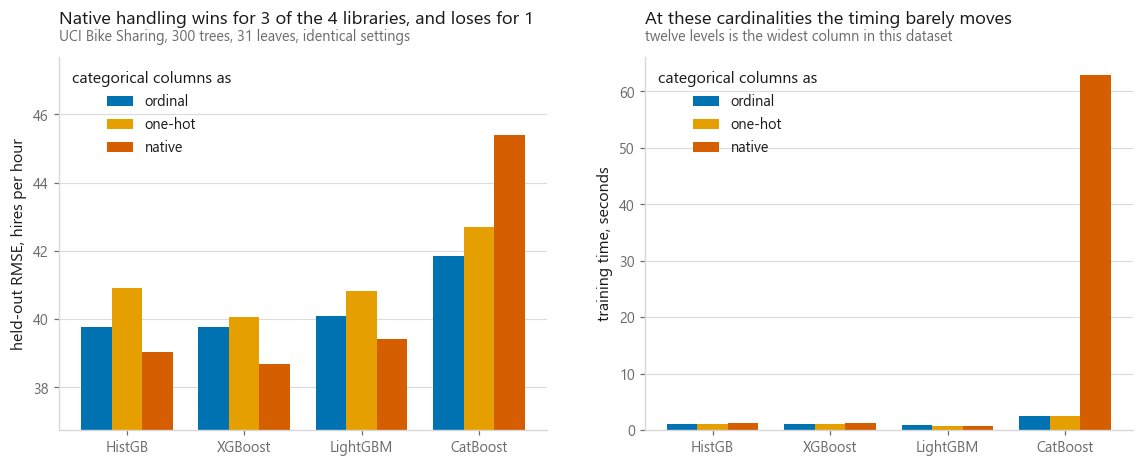

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))
width = 0.26
slots = np.arange(len(CONTENDERS))

for i, mode in enumerate(MODES):
    subset = cat_frame[cat_frame["encoding"] == mode].set_index("library")
    colour = style.HIGHLIGHT if mode == "native" else style.PALETTE[i]
    axes[0].bar(slots + (i - 1) * width,
                [subset.loc[name, "RMSE"] for name in CONTENDERS],
                width, color=colour, label=mode)
    axes[1].bar(slots + (i - 1) * width,
                [subset.loc[name, "fit seconds"] for name in CONTENDERS],
                width, color=colour, label=mode)

axes[0].set_xticks(slots, CONTENDERS)
axes[0].set_ylabel("held-out RMSE, hires per hour")
axes[0].set_ylim(bottom=min(cat_frame["RMSE"]) * 0.95)
axes[0].legend(title="categorical columns as")
style.title(axes[0],
            f"Native handling wins for {len(NATIVE_WINS)} of the {len(CONTENDERS)} "
            f"libraries, and loses for {len(NATIVE_LOSES)}",
            "UCI Bike Sharing, 300 trees, 31 leaves, identical settings")

axes[1].set_xticks(slots, CONTENDERS)
axes[1].set_ylabel("training time, seconds")
axes[1].legend(title="categorical columns as")
style.title(axes[1], "At these cardinalities the timing barely moves",
            "twelve levels is the widest column in this dataset")

style.save(fig, FIG / "fig-03-categorical.png")

Start with the library that breaks the pattern, because it is the more
interesting row. For CatBoost, native handling is the worst of its three
encodings, and its native fit is the slowest cell in the whole table by a
wide margin. That is the opposite of what the section heading promises, and
it is not a bug.

The reason is in the columns I declared. `mnth` and `weekday` arrive as
integers that carry a real order: any month really does sit between the one
before it and the one after, and bike hire follows that order closely.
Declaring them categorical throws that order away and replaces each level with
an ordered target statistic, so CatBoost has to rediscover from noisy
per-level estimates something the ordinal codes handed it for free. The cost
side comes from the same choice: those statistics are built over several
permutations, and that is where the fitting time goes.

So the lesson is narrower than "declare your categoricals". Declare the
columns whose levels have no order. `season` and `weathersit` qualify. `mnth`
and `weekday` are only nominally labels: their codes carry an order that is
real, and a model splitting on them numerically is already using information
that target encoding throws away.

For the other libraries the expected pattern does hold: native handling wins,
ordinal codes come second, one-hot comes last. That last part surprised me. I
expected the invented ordering in the ordinal codes to be the worst thing on
the chart, and instead the tree recovers from it well: it can carve a fake
ordering into pieces with two or three splits, whereas one-hot forces it to
find several low-gain splits that only pay off together.

The timing panel does not show what I expected either, and I would rather say
so than crop it. The widest column here has twelve levels, so one-hot adds a
couple of dozen columns and almost no work. One-hot gets expensive when
cardinality reaches the hundreds or thousands: a postcode, a product id, a
user id. So let me build that case out of columns this dataset already has, by
crossing weekday with hour of day into an hour-of-week label.

One practical limit decides the size of that column. Scikit-learn's
`HistGradientBoosting` bins categories the same way it bins numbers, so a
declared categorical feature must have fewer levels than `max_bins`, which
caps at 255. Cross month with hour instead of weekday with hour and it raises
a `ValueError` rather than falling back. LightGBM and CatBoost have no such
ceiling.

In [11]:
X_wide = X_bike.copy()
X_wide["hour_of_week"] = X_wide["weekday"] * 24 + X_wide["hr"]   # a label, not a quantity
WIDE_CATEGORICAL = CATEGORICAL + ["hour_of_week"]
print(f"hour_of_week has {X_wide['hour_of_week'].nunique()} levels, "
      f"against a HistGB ceiling of 255")

wide_results = []
for library in CONTENDERS:
    for mode in ["one-hot", "native"]:
        frame = encode(X_wide, mode, library, WIDE_CATEGORICAL)
        train_X, test_X, train_y, test_y = train_test_split(
            frame, y_bike, test_size=0.25, random_state=SEED)
        model = regressor(library, mode, columns=WIDE_CATEGORICAL, n_estimators=200)
        start = time.perf_counter()
        model.fit(train_X, train_y)
        fit_seconds = time.perf_counter() - start
        rmse = float(np.sqrt(np.mean((test_y.values - model.predict(test_X)) ** 2)))
        wide_results.append({"library": library, "encoding": mode,
                             "columns": frame.shape[1], "RMSE": rmse,
                             "fit seconds": fit_seconds})

wide_frame = pd.DataFrame(wide_results)
print(wide_frame.round(3).to_string(index=False))
print()
for library in CONTENDERS:
    rows = wide_frame[wide_frame["library"] == library].set_index("encoding")
    ratio = rows.loc["one-hot", "fit seconds"] / rows.loc["native", "fit seconds"]
    verdict = "slower" if ratio > 1 else "faster"
    print(f"{library:<10} one-hot was {ratio:.1f}x the time of native handling ({verdict})")

hour_of_week has 168 levels, against a HistGB ceiling of 255


 library encoding  columns   RMSE  fit seconds
  HistGB  one-hot      203 42.167        3.442
  HistGB   native       13 41.765        0.828
 XGBoost  one-hot      203 43.313        1.375
 XGBoost   native       13 43.609        1.087
LightGBM  one-hot      203 42.397        0.856
LightGBM   native       13 42.311        0.967
CatBoost  one-hot      203 48.387        2.835
CatBoost   native       13 45.088       45.514

HistGB     one-hot was 4.2x the time of native handling (slower)
XGBoost    one-hot was 1.3x the time of native handling (slower)
LightGBM   one-hot was 0.9x the time of native handling (faster)
CatBoost   one-hot was 0.1x the time of native handling (faster)


Now the timing separates, and it separates by library rather than by encoding,
which is the interesting part.

`HistGradientBoosting` pays the full price. Every one of those dummy columns
gets binned, and then gets scanned at every node of every tree, so the fit time
tracks the width of the matrix.

LightGBM barely notices, and can even come out ahead of its own native
handling. That is not luck. LightGBM does **exclusive feature bundling**: it
looks for groups of features that are never non-zero on the same row and packs
them back into a single column, and one-hot dummies from the same source column
are exactly that by construction. It undoes the one-hot before it starts
training. Meanwhile its native categorical path has a real per-node cost of its
own, since it sorts the categories by accumulated gradient at every node.

So the usual advice, "never one-hot for a boosted tree, it is slow", is true for
some of these libraries and not others. The speed argument does not hold
everywhere, and neither does the accuracy argument: read the RMSE column above
rather than taking either on trust. One library scores better one-hot than
native on the wider column, and CatBoost prefers plain ordinal codes to its own
native path on both, for the reason given below.

### 4.2 CatBoost and the leak in target encoding

There is a fourth encoding I skipped, and it is the one that gets people into
trouble.

**Target encoding** replaces a category with the mean target for that category.
It is compact, it carries real signal, and it leaks. The row you are encoding
contributed to the mean you are encoding it with, so the feature contains a
piece of that row's own answer. For a category holding two rows, the encoded
value is roughly half the answer. Training error falls, held-out error rises,
and the model looks fine until it ships.

The usual patch is to compute the means out of fold. CatBoost's answer is
**ordered target statistics** and it is tidier. It draws a random permutation
of the rows and treats it as if it were time: when it encodes row $i$, it
averages the target over only the rows that came before $i$ in that
permutation.

$$\hat{x}_i = \frac{\sum_{j < i} [\, x_j = x_i \,] \, y_j + a \, p}{\sum_{j < i} [\, x_j = x_i \,] + a}$$

The $a\,p$ term is a prior with weight $a$, which stops a category seen once
from taking that single target as its value. Row $i$ never contributes to its
own encoding, so the leak closes by construction. Several permutations are kept
and rotated, so that rows landing early in one ordering are not stuck with a
noisy estimate everywhere.

The same idea applied to gradients rather than features is what CatBoost calls
**ordered boosting**, and it is where its reputation on small datasets comes
from. It costs time, which is part of why CatBoost is usually the slowest of
the three to fit.

Here is the leak, measured. No CatBoost needed: the point is about the
encoding, and both versions are a few lines of pandas. To make it unambiguous I
encode a column that is pure noise, generated with no relationship to the
target at all. Any apparent signal it produces is manufactured by the encoding.

In [12]:
noise_rng = np.random.default_rng(SEED)
leak_frame = X_bike.copy()
leak_frame["noise_id"] = noise_rng.integers(0, 400, len(leak_frame))

leak_train, leak_test, leak_y_train, leak_y_test = train_test_split(
    leak_frame, y_bike, train_size=1500, test_size=4000, random_state=SEED)

prior = float(leak_y_train.mean())
SMOOTHING = 10.0

# Naive: one mean per category, computed over every training row.
naive_map = leak_y_train.groupby(leak_train["noise_id"]).mean()
naive_encoded = leak_train["noise_id"].map(naive_map).values

# Ordered: walk a random permutation and average only over the rows seen so far.
running_sum, running_count = {}, {}
ordered_encoded = np.empty(len(leak_train))
for position in noise_rng.permutation(len(leak_train)):
    category = leak_train["noise_id"].iloc[position]
    total, count = running_sum.get(category, 0.0), running_count.get(category, 0)
    ordered_encoded[position] = (total + SMOOTHING * prior) / (count + SMOOTHING)
    running_sum[category] = total + leak_y_train.iloc[position]
    running_count[category] = count + 1

# At prediction time both use the full training statistics. That is not the leak.
test_encoded = leak_test["noise_id"].map(naive_map).fillna(prior).values

base_train = leak_train.drop(columns="noise_id").astype(float)
base_test = leak_test.drop(columns="noise_id").astype(float)

print(f"{'':<32} {'train RMSE':>11} {'held out':>10} {'gap':>8}")
for label, train_X, test_X in [
        ("column left out entirely", base_train, base_test),
        ("naive target encoding", base_train.assign(encoded=naive_encoded),
         base_test.assign(encoded=test_encoded)),
        ("ordered target statistics", base_train.assign(encoded=ordered_encoded),
         base_test.assign(encoded=test_encoded))]:
    model = HistGradientBoostingRegressor(max_iter=200, max_leaf_nodes=31,
                                          early_stopping=False, random_state=SEED)
    model.fit(train_X, leak_y_train)
    train_rmse = float(np.sqrt(np.mean((leak_y_train.values - model.predict(train_X)) ** 2)))
    test_rmse = float(np.sqrt(np.mean((leak_y_test.values - model.predict(test_X)) ** 2)))
    print(f"{label:<32} {train_rmse:>11.2f} {test_rmse:>10.2f} {test_rmse - train_rmse:>8.2f}")

print("\nThe naive encoding of a column that means nothing improves training error")
print("and damages held-out error. The ordered version lands close to leaving the")
print("column out, which is the right answer for a column that carries no signal.")

                                  train RMSE   held out      gap


column left out entirely               19.31      53.81    34.50


naive target encoding                  15.46      77.22    61.77


ordered target statistics              17.22      57.10    39.88

The naive encoding of a column that means nothing improves training error
and damages held-out error. The ordered version lands close to leaving the
column out, which is the right answer for a column that carries no signal.


## 5. The benchmark, and how much is the library rather than the tuning

Now the comparison everyone wants, done in a way that means something.

Most benchmarks online compare the libraries at their own defaults. That
measures the defaults, not the libraries, and the defaults differ wildly:
LightGBM builds 100 trees of 31 leaves, XGBoost builds 100 trees of depth 6,
CatBoost builds a thousand trees, and scikit-learn switches early stopping on
by itself once the data is large enough. Comparing those four is comparing four
different amounts of model.

So I run it twice. Once at each library's own defaults, which is the number you
get if you type three lines and stop. Once with the same tree count, learning
rate, leaf budget and bin count forced on all of them, which is the number that
says something about the implementation.

In [13]:
def default_classifier(library):
    if library == "HistGB":
        return HistGradientBoostingClassifier(random_state=SEED)
    if library == "LightGBM":
        return lgb.LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1)
    if library == "XGBoost":
        return xgb.XGBClassifier(random_state=SEED, n_jobs=-1, verbosity=0)
    if library == "CatBoost":
        # The true default is 1000 iterations. Capped here so this notebook stays
        # under five minutes, and the fact that it needs capping is worth knowing.
        return cb.CatBoostClassifier(iterations=300, random_seed=SEED, verbose=0,
                                     thread_count=-1, allow_writing_files=False)
    raise ValueError(library)


def benchmark(model, train_X, train_y, test_X, test_y):
    start = time.perf_counter()
    model.fit(train_X, train_y)
    fit_seconds = time.perf_counter() - start

    start = time.perf_counter()
    predictions = model.predict(test_X)
    predict_seconds = time.perf_counter() - start

    return {"accuracy": share_correct(predictions, test_y.values),
            "fit seconds": fit_seconds,
            "predict microseconds per row": predict_seconds / len(test_X) * 1e6}


rows = []
for library in CONTENDERS:
    for setting, model in [
            ("its own defaults", default_classifier(library)),
            ("matched settings", classifier(library, n_estimators=200, learning_rate=0.1,
                                            num_leaves=31, max_bin=255))]:
        rows.append({"library": library, "setting": setting,
                     **benchmark(model, Xb_train, yb_train, Xb_test, yb_test)})

bench = pd.DataFrame(rows)
print(bench.round(4).to_string(index=False))

for setting in ["its own defaults", "matched settings"]:
    subset = bench[bench["setting"] == setting]
    print(f"\n{setting}: accuracy spread across libraries "
          f"{subset['accuracy'].max() - subset['accuracy'].min():.4f}, "
          f"fastest fit {subset['fit seconds'].min():.2f}s, "
          f"slowest {subset['fit seconds'].max():.2f}s")

 library          setting  accuracy  fit seconds  predict microseconds per row
  HistGB its own defaults    0.9257       2.8840                       19.3713
  HistGB matched settings    0.9277      11.3700                      111.2464
 XGBoost its own defaults    0.9268       2.2617                        6.7069
 XGBoost matched settings    0.9262      11.8332                       12.4531
LightGBM its own defaults    0.9301       3.9419                       11.5172
LightGBM matched settings    0.9254       3.6128                       23.7042
CatBoost its own defaults    0.9283       6.0535                        4.0092
CatBoost matched settings    0.9262       4.6627                        5.0289

its own defaults: accuracy spread across libraries 0.0044, fastest fit 2.26s, slowest 6.05s

matched settings: accuracy spread across libraries 0.0024, fastest fit 3.61s, slowest 11.83s



binomial standard error on one accuracy over 3,403 held-out rows: 0.0045
accuracy spread across all libraries and both settings: 0.0047
fit-time spread across the same rows: 5.2x


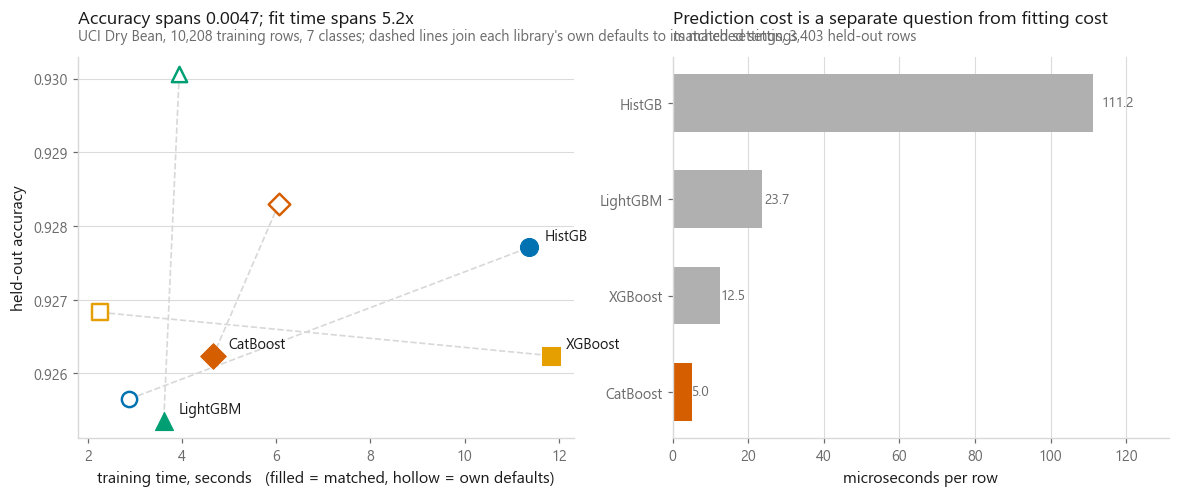

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.5))

matched = bench[bench["setting"] == "matched settings"].reset_index(drop=True)
defaults = bench[bench["setting"] == "its own defaults"].reset_index(drop=True)

for i, row in matched.iterrows():
    axes[0].scatter(row["fit seconds"], row["accuracy"], s=140, zorder=3,
                    color=style.PALETTE[i], marker=style.MARKERS[i])
    axes[0].annotate(row["library"], xy=(row["fit seconds"], row["accuracy"]),
                     xytext=(10, 5), textcoords="offset points",
                     fontsize=9.5, color=style.INK)
for i, row in defaults.iterrows():
    axes[0].scatter(row["fit seconds"], row["accuracy"], s=100, zorder=2,
                    facecolor="white", edgecolor=style.PALETTE[i], linewidth=1.6,
                    marker=style.MARKERS[i])
    partner = matched[matched["library"] == row["library"]].iloc[0]
    axes[0].plot([row["fit seconds"], partner["fit seconds"]],
                 [row["accuracy"], partner["accuracy"]],
                 color=style.RULE, lw=1.1, ls="--", zorder=1)

axes[0].set_xlabel("training time, seconds   (filled = matched, hollow = own defaults)")
axes[0].set_ylabel("held-out accuracy")
style.title(axes[0],
            f"Accuracy spans {bench['accuracy'].max() - bench['accuracy'].min():.4f}; "
            f"fit time spans {bench['fit seconds'].max() / bench['fit seconds'].min():.1f}x",
            f"UCI Dry Bean, {len(Xb_train):,} training rows, 7 classes; "
            f"dashed lines join each library's own defaults to its matched settings")

order = matched.sort_values("predict microseconds per row")
axes[1].barh(list(order["library"]), list(order["predict microseconds per row"]),
             color=[style.HIGHLIGHT] + [style.NEUTRAL] * (len(order) - 1), height=0.6)
for i, value in enumerate(order["predict microseconds per row"]):
    axes[1].text(value * 1.02, i, f"{value:.1f}", va="center",
                 fontsize=9, color=style.MUTED)
axes[1].set_xlabel("microseconds per row")
axes[1].set_xlim(0, max(order["predict microseconds per row"]) * 1.18)
axes[1].grid(axis="y", visible=False)
axes[1].grid(axis="x", visible=True)
style.title(axes[1], "Prediction cost is a separate question from fitting cost",
            f"matched settings, {len(Xb_test):,} held-out rows")

style.save(fig, FIG / "fig-04-accuracy-vs-time.png")

# The accuracy axis of that chart spans less than the noise on a single held-out
# accuracy, which is the reason the section is written the way it is. Print both.
se_bench = float(np.sqrt(bench["accuracy"].mean() * (1 - bench["accuracy"].mean())
                         / len(Xb_test)))
print(f"\nbinomial standard error on one accuracy over {len(Xb_test):,} held-out rows: "
      f"{se_bench:.4f}")
print(f"accuracy spread across all libraries and both settings: "
      f"{bench['accuracy'].max() - bench['accuracy'].min():.4f}")
print(f"fit-time spread across the same rows: "
      f"{bench['fit seconds'].max() / bench['fit seconds'].min():.1f}x")

Two axes, two different stories, and the standard error printed above is what
separates them.

The vertical axis is a tie. The whole accuracy spread, across four libraries and
both the default and matched settings, is comparable to the noise on any one of
those numbers. **This benchmark does not rank the libraries on accuracy**, and no
benchmark on one dataset of this size could. That is not a disappointing result;
it is the result, and it is what the rest of the section is built on.

The horizontal axis separates cleanly, by a multiple rather than a fraction. Fit
time varies several-fold across the same four rows that tie on accuracy, and the
dashed lines connecting each library's two markers show how much of that is the
defaults rather than the implementation. A library whose default builds a
thousand trees will look slow and accurate against one whose default builds a
hundred, and neither fact is about the code.

So the useful comparison is the one that survives: pick on the axis that has a
gap on it. That is time, memory, categorical handling and what you already have
installed, all of which this notebook measures, and none of which is accuracy.

### How they scale with rows

Fitting time at one dataset size tells you almost nothing, because the fixed
overheads differ. The shape of the curve is the useful part. Bike Sharing is
the larger of the two datasets here, and I resample it with replacement to get
past its natural size: that makes any accuracy meaningless, which is fine,
because this cell only measures time.

library        2,500     5,000    10,000    20,000    40,000    80,000   160,000
HistGB          0.59      0.64      0.80      0.78      1.12      1.24      0.85
XGBoost         0.53      0.50      0.55      0.70      0.73      0.60      0.59
LightGBM        0.30      0.42      0.43      0.51      0.53      0.55      0.56
CatBoost        0.47      0.63      0.89      1.10      1.76      2.01      3.44

seconds to fit 100 trees. Slope on the log-log plot, fitted over the whole
range and over the last four sizes alone. 1.00 is exactly linear in rows:
  HistGB      0.14 over all of it    0.05 over the large end
  XGBoost     0.05 over all of it   -0.11 over the large end
  LightGBM    0.14 over all of it    0.05 over the large end
  CatBoost    0.46 over all of it    0.51 over the large end


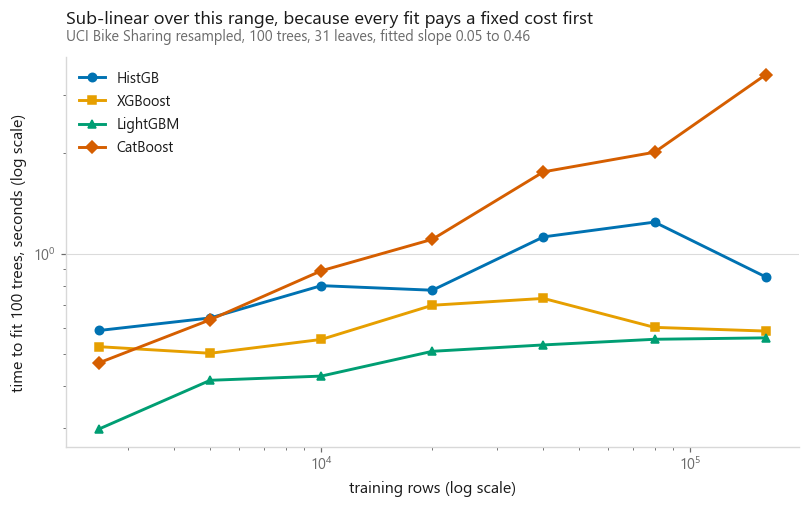

In [15]:
row_counts = [2_500, 5_000, 10_000, 20_000, 40_000, 80_000, 160_000]
scaling = {library: [] for library in CONTENDERS}
sampler = np.random.default_rng(SEED)

X_scale = X_bike.astype(float).values
y_scale = y_bike.values

for n in row_counts:
    picks = sampler.integers(0, len(X_scale), n)
    Xn, yn = X_scale[picks], y_scale[picks]
    for library in CONTENDERS:
        # Best of two again. One background process waking up mid-sweep is enough
        # to put a spike in the middle of the curve and bend the fitted slope.
        scaling[library].append(timed(
            lambda: regressor(library, "ordinal", n_estimators=100,
                              num_leaves=31).fit(Xn, yn), repeat=2))

def log_log_slope(counts, times):
    """Fitted exponent: 1.0 means time is exactly proportional to rows."""
    return float(np.polyfit(np.log(counts), np.log(times), 1)[0])


full_slope = {library: log_log_slope(row_counts, scaling[library])
              for library in CONTENDERS}
# The last four sizes on their own, where the fixed cost per fit has been
# outgrown by the per-row work and the true exponent starts to show.
tail_slope = {library: log_log_slope(row_counts[-4:], scaling[library][-4:])
              for library in CONTENDERS}

fig, ax = plt.subplots(figsize=(8.6, 4.6))
for i, library in enumerate(CONTENDERS):
    ax.plot(row_counts, scaling[library], marker=style.MARKERS[i],
            color=style.PALETTE[i], label=library)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("training rows (log scale)")
ax.set_ylabel("time to fit 100 trees, seconds (log scale)")
ax.legend()
style.title(ax, "Sub-linear over this range, because every fit pays a fixed cost first",
            f"UCI Bike Sharing resampled, 100 trees, 31 leaves, fitted slope "
            f"{min(full_slope.values()):.2f} to {max(full_slope.values()):.2f}")
style.save(fig, FIG / "fig-05-scaling.png")

print(f"{'library':<10}" + "".join(f"{n:>10,}" for n in row_counts))
for library in CONTENDERS:
    print(f"{library:<10}" + "".join(f"{t:>10.2f}" for t in scaling[library]))
print("\nseconds to fit 100 trees. Slope on the log-log plot, fitted over the whole")
print("range and over the last four sizes alone. 1.00 is exactly linear in rows:")
for library in CONTENDERS:
    print(f"  {library:<10} {full_slope[library]:>5.2f} over all of it"
          f"   {tail_slope[library]:>5.2f} over the large end")

A slope of one would mean doubling the rows doubles the time, which is the best
anything that has to read every row can do. These lines come out well under
that, and the reason sits at the small end of the chart rather than the large
one.

Fitting a hundred trees costs something before a single row is touched:
allocating the booster, binning the columns, waking the thread pool. On a few
thousand rows that fixed cost is most of what the clock sees, so the left of
the chart sits higher than the per-row work alone would put it, and a straight
line through all seven points comes out too shallow. Fit the slope over the
larger sizes alone, where the per-row work has grown past that fixed cost, and
you get the second number printed above. It keeps climbing towards one on data
big enough to make the fixed cost irrelevant.

That fixed cost is worth remembering whenever you time anything: on small data
you are measuring the setup, not the algorithm. The comparison that does hold
is against the exact method in the
[previous notebook](../05-gradient-boosting/), which carries a $\log n$ factor
on top of the per-row work and a much larger constant underneath it.

### The part nobody puts in the benchmark

Here is the question I actually care about. The gap between these libraries at
matched settings is small. Is it larger or smaller than the gap between a bad
configuration and a good one *within* one library?

I run the same six configurations through every library, and compare two
numbers: how much accuracy moves when the library changes and the settings hold
still, against how much it moves when the settings change and the library holds
still.

One split would not settle this. The two quantities being compared are both
small, so the ordering between them can turn over on sampling noise alone.
I run the whole grid on several train/test splits and print the comparison for
each, which is the only version of this measurement I would believe.

In [16]:
GRID = [
    {"n_estimators": 100, "learning_rate": 0.30, "num_leaves": 15, "max_bin": 255},
    {"n_estimators": 150, "learning_rate": 0.10, "num_leaves": 31, "max_bin": 255},
    {"n_estimators": 200, "learning_rate": 0.05, "num_leaves": 63, "max_bin": 255},
    {"n_estimators": 300, "learning_rate": 0.05, "num_leaves": 15, "max_bin": 127},
    {"n_estimators": 100, "learning_rate": 0.10, "num_leaves": 127, "max_bin": 63},
    {"n_estimators": 200, "learning_rate": 0.20, "num_leaves": 7, "max_bin": 255},
]

CONFIG_LABELS = [f"{c['n_estimators']} trees, lr {c['learning_rate']}, "
                 f"{c['num_leaves']} leaves, {c['max_bin']} bins" for c in GRID]

# Four splits rather than one, because the two spreads being compared are close
# enough together that a single split cannot tell them apart.
SPLIT_SEEDS = [SEED, SEED + 1, SEED + 2, SEED + 3]


def grid_scores(split_seed):
    """Every configuration against every library, on one train/test split.

    A smaller slice than the benchmark above, so six configurations times
    however many libraries are installed times four splits stays quick.
    """
    train_X, test_X, train_y, test_y = train_test_split(
        X_bean, y_bean_coded, train_size=4500, test_size=3500,
        random_state=split_seed, stratify=y_bean_coded)
    out = np.zeros((len(GRID), len(CONTENDERS)))
    for row, config in enumerate(GRID):
        for column, library in enumerate(CONTENDERS):
            model = classifier(library, seed=split_seed, **config)
            model.fit(train_X, train_y)
            out[row, column] = share_correct(model.predict(test_X), test_y.values)
    return out


by_seed = {split_seed: grid_scores(split_seed) for split_seed in SPLIT_SEEDS}
scores = by_seed[SPLIT_SEEDS[0]]

grid_frame = pd.DataFrame(scores, columns=CONTENDERS)
grid_frame.insert(0, "configuration", CONFIG_LABELS)
print("first split in full\n")
print(grid_frame.round(4).to_string(index=False))

tuning_spread = float(np.mean(scores.max(axis=0) - scores.min(axis=0)))
library_spread = float(np.mean(scores.max(axis=1) - scores.min(axis=1)))

print(f"\nchange the settings, hold the library : accuracy moves {tuning_spread:.4f} on average")
print(f"change the library, hold the settings : accuracy moves {library_spread:.4f} on average")

# Now the same two numbers on every split, which is what decides whether the
# ordering between them means anything.
print(f"\n{'split':>6} {'settings move':>15} {'library moves':>15} {'ratio':>8} "
      f"{'whole table':>13}")
ratios, bands = [], []
for split_seed in SPLIT_SEEDS:
    seed_scores = by_seed[split_seed]
    tuning = float(np.mean(seed_scores.max(axis=0) - seed_scores.min(axis=0)))
    library = float(np.mean(seed_scores.max(axis=1) - seed_scores.min(axis=1)))
    band = float(seed_scores.max() - seed_scores.min())
    ratios.append(tuning / library)
    bands.append(band)
    print(f"{split_seed:>6} {tuning:>15.4f} {library:>15.4f} "
          f"{tuning / library:>8.2f} {band:>13.4f}")

print(f"\nthe ratio runs {min(ratios):.2f} to {max(ratios):.2f} across "
      f"{len(SPLIT_SEEDS)} splits")
if min(ratios) < 1.0 < max(ratios):
    print("and crosses 1.00, so neither effect is reliably the larger one here")
else:
    larger = "settings" if min(ratios) > 1.0 else "library"
    print(f"and stays one side of 1.00, so the {larger} is the larger effect here")
print(f"best configuration and library minus worst, within a split: "
      f"{min(bands):.4f} to {max(bands):.4f}")

best = np.unravel_index(int(np.argmax(scores)), scores.shape)
worst = np.unravel_index(int(np.argmin(scores)), scores.shape)
print(f"\non the first split, best  : {CONTENDERS[best[1]]:<10} "
      f"{CONFIG_LABELS[best[0]]}  ({scores[best]:.4f})")
print(f"on the first split, worst : {CONTENDERS[worst[1]]:<10} "
      f"{CONFIG_LABELS[worst[0]]}  ({scores[worst]:.4f})")

first split in full

                          configuration  HistGB  XGBoost  LightGBM  CatBoost
 100 trees, lr 0.3, 15 leaves, 255 bins  0.9123   0.9169    0.9129    0.9209
 150 trees, lr 0.1, 31 leaves, 255 bins  0.9154   0.9180    0.9129    0.9217
200 trees, lr 0.05, 63 leaves, 255 bins  0.9189   0.9163    0.9166    0.9223
300 trees, lr 0.05, 15 leaves, 127 bins  0.9149   0.9171    0.9160    0.9251
 100 trees, lr 0.1, 127 leaves, 63 bins  0.9171   0.9220    0.9180    0.9231
  200 trees, lr 0.2, 7 leaves, 255 bins  0.9157   0.9194    0.9140    0.9240

change the settings, hold the library : accuracy moves 0.0054 on average
change the library, hold the settings : accuracy moves 0.0083 on average

 split   settings move   library moves    ratio   whole table
     0          0.0054          0.0083     0.66        0.0129
     1          0.0047          0.0057     0.83        0.0114
     2          0.0060          0.0049     1.22        0.0080
     3          0.0040          0.0038     1

That table is the honest answer to "which one should I use", and it is not a
ranking of libraries.

The two spreads come out the same size, and the ratio between them lands on
either side of one depending on which split you look at. Neither the library
nor the configuration is reliably the larger lever on this task. I had written
the opposite here before running it on more than one split, on the strength of
a single number that turned out to be a coin toss.

What does hold across every split is the width of the band. Every
configuration, every library, every split: the whole table sits inside the
range printed above, and that range is narrow. This is the more useful finding
and a stronger one than a ranking would have been. When the entire menu
finishes that close together, accuracy is not the variable worth optimising,
because there is very little left in it to win. If you are picking between
XGBoost, LightGBM and CatBoost on the strength of a leaderboard where they
finish within a fraction of a percent of each other, you are optimising the
wrong thing.

Decide instead on the axes that actually separate, and this notebook has already
measured all of them. Where these libraries genuinely differ is on things that
are not accuracy. Every one of those gaps is a multiple rather than a fraction,
which makes them all wider than the accuracy difference you would otherwise be
choosing on.

**Speed of fitting.** LightGBM is usually fastest, and the gap widens with
rows. This matters during a cross-validated search, because you pay it dozens
of times over.

**Speed of prediction.** CatBoost's oblivious trees evaluate as an array index
rather than a tree walk, which is a real advantage when you are serving under a
latency budget.

**Categorical columns.** With many high-cardinality columns, CatBoost's ordered
statistics is the least work for the best result, and LightGBM's set splitting
is close behind.

**Small datasets.** CatBoost's ordered boosting is built for the case where the
others overfit. Leaf-wise growth is the most dangerous here, and section 3
showed the minimum rows per leaf matters more for that than the leaf budget.

**Installing nothing.** `HistGradientBoosting` is already there, it lands
within noise of the others, and it keeps a dependency out of your project. For
a lot of work that is the right trade, and it is the one I make by default.

## Cheat sheet

| Situation | Reach for |
|---|---|
| A strong tabular baseline in three lines with no new dependency | `HistGradientBoostingClassifier`, already installed |
| Millions of rows, or a search over hundreds of configurations | LightGBM, the fastest to fit |
| Many high-cardinality categorical columns | CatBoost, then LightGBM |
| A few thousand rows and no room to overfit | CatBoost, or leaf-wise with the minimum rows per leaf left alone |
| Serving predictions under a latency budget | CatBoost, oblivious trees index rather than walk |
| GPU training and the widest platform support | XGBoost |
| A categorical column with more than 255 levels | Anything except `HistGradientBoosting`, which refuses |

| Dial | XGBoost | LightGBM | CatBoost | HistGB |
|---|---|---|---|---|
| Number of trees | `n_estimators` | `n_estimators` | `iterations` | `max_iter` |
| Step size | `learning_rate` | `learning_rate` | `learning_rate` | `learning_rate` |
| Tree size | `max_depth` | `num_leaves` | `depth` | `max_leaf_nodes` |
| Rows per leaf | none, `min_child_weight` counts Hessian mass | `min_child_samples` | `min_data_in_leaf` | `min_samples_leaf` |
| Bins | `max_bin` | `max_bin` | `border_count` | `max_bins` |
| Categorical | `enable_categorical=True` | pandas `category` dtype | `cat_features=[...]` | `categorical_features=[...]` |
| Quiet | `verbosity=0` | `verbose=-1` | `verbose=0` | quiet already |
| Shape out of `predict` | `(n,)` | `(n,)` | `(n, 1)` on multiclass | `(n,)` |

## What to remember

1. All four are the same algorithm. The differences are engineering, and the
   engineering has largely converged.
2. Histogram binning is what made boosting practical. It removes the per-node
   sort and caps the split search at `max_bin` positions however many rows you
   have.
3. Sibling subtraction gets a node's histogram from its parent and its sibling
   for nothing, which removes about half the accumulation work.
4. Level-wise grows balanced, leaf-wise grows lopsided and deep, oblivious
   grows one condition per level. Leaf-wise fits the training data hardest and
   overfits small data fastest.
5. The minimum rows per leaf protects you from leaf-wise growth more than the
   leaf budget does. I had that backwards before I measured it.
6. Ordinal codes invent an order that is not in the data, and trees recover
   from that better than I expected. One-hot was the worst of the three on
   error for most of these libraries, but not all of them: declaring a column
   categorical when its integer codes carry a real order throws that order
   away, and CatBoost paid for it in both error and fitting time.
7. One-hot costs fitting time for some libraries and not others. LightGBM
   bundles the dummies back together before training, so the usual blanket
   advice does not hold.
8. Target encoding leaks, because the row being encoded sits inside the mean.
   Ordered target statistics averages only over rows earlier in a random
   permutation, which closes the leak by construction.
9. Benchmarks at default settings measure the defaults. Force the same tree
   count, learning rate, leaf budget and bin count before comparing anything.
10. Tuning and the choice of library move accuracy by comparable amounts here,
    and across every split I tried neither was reliably the larger. The whole
    table lands in a narrow band, so choose on fitting speed, prediction
    speed, categorical support and how much you enjoy the API, all of which
    separate by far more, then go and tune.
11. Check the shape of what `predict` gives you before comparing it to
    anything. A column against a vector broadcasts into a matrix instead of
    raising, and the mean of that matrix is a plausible-looking score that no
    hyperparameter can move. A number that ignores every setting you change is
    not a badly tuned model.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [04-07 Stacking and voting](../07-stacking-and-voting/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#XGBoost` `#LightGBM` `#CatBoost` `#GradientBoosting`
`#Python` `#ScikitLearn` `#DataScience` `#MLTutorial` `#Ensemble`